# 实验目的
1. **理解基于实例学习的基本原理与特点**
2. **掌握K近邻（KNN）算法的核心思想与实现**
3. **学会使用距离度量方法处理不同类型数据**
4. **掌握K值选择对模型性能的影响**
5. **理解基于实例学习在实际问题中的应用场景**

# 实验原理

## 1. 基于实例学习概述

基于实例的学习（Instance-Based Learning）是一种“懒惰学习”方法，其核心思想包括：

- 不构建显式的全局模型
- 将训练数据存储为实例集合
- 对新实例的预测基于与其最相似的训练实例

典型算法有：K近邻（KNN）、局部加权回归等。

## 2. K近邻（KNN）算法原理

KNN算法的基本步骤如下：

1. 存储所有训练实例
2. 计算新样本与所有训练样本的距离
3. 选择距离最近的K个邻居
4. 基于K个邻居的类别进行投票（分类）或取平均值（回归）
5. 返回预测结果

## 3. 关键概念与公式

### (1) 距离度量

常用的距离度量方法：

- **欧氏距离（Euclidean Distance）**  
    $$
    d(x, y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
    $$

- **曼哈顿距离（Manhattan Distance）**  
    $$
    d(x, y) = \sum_{i=1}^n |x_i - y_i|
    $$

- **余弦相似度（Cosine Similarity）**  
    $$
    \text{cosine}(x, y) = \frac{x \cdot y}{\|x\| \cdot \|y\|}
    $$

---

### (2) K值选择

K值对模型性能有显著影响：

- 小K值：模型复杂度高，容易过拟合
- 大K值：模型复杂度低，可能欠拟合
- 通常通过交叉验证选择最优K值

---

### (3) 特征缩放

由于距离计算对特征尺度敏感，通常需要进行特征缩放：

- **标准化（Z-score）：**
    $$
    x' = \frac{x - \mu}{\sigma}
    $$

- **归一化（Min-Max）：**
    $$
    x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
    $$


# 实验步骤


## 1. 数据准备 
**使⽤鸢尾花数据集(Iris):**

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 加载数据
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)
# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. KNN核⼼算法实现

### (1) 距离计算函数

In [7]:
import numpy as np

def euclidean_distance(x1, x2):
    """计算欧氏距离"""
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    """计算曼哈顿距离"""
    return np.sum(np.abs(x1 - x2))

def cosine_similarity(x1, x2):
    """计算余弦相似度"""
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    return dot_product / (norm_x1 * norm_x2)

### (2) KNN分类器实现

In [8]:
class KNN:
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        # 计算距离
        if self.distance_metric == 'euclidean':
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        elif self.distance_metric == 'manhattan':
            distances = [manhattan_distance(x, x_train) for x_train in self.X_train]
        elif self.distance_metric == 'cosine':
            similarities = [cosine_similarity(x, x_train) for x_train in self.X_train]
            distances = [1 - sim for sim in similarities]
        else:
            raise ValueError("不支持的度量方法")

        # 获取最近的k个邻居
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]

        # 投票决定类别
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common


## 3. 模型训练与评估

测试集准确率: 1.0000


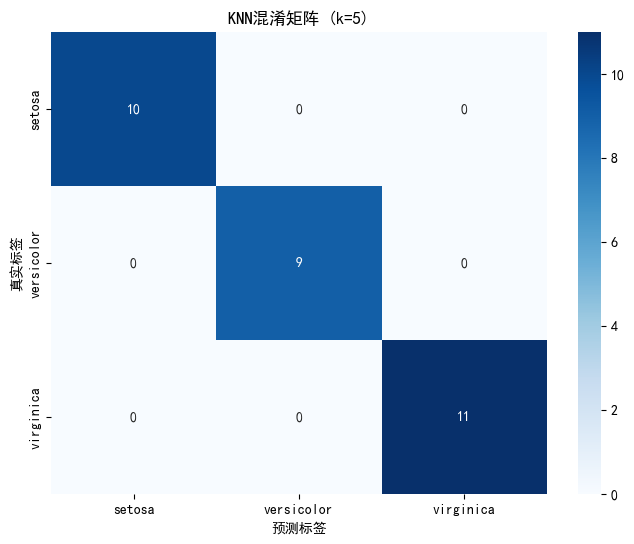

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 初始化模型
knn = KNN(k=5, distance_metric='euclidean')
# 训练模型
knn.fit(X_train, y_train)
# 预测
y_pred = knn.predict(X_test)
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {accuracy:.4f}")
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('KNN混淆矩阵 (k=5)')
plt.show()

## 4. K值影响分析

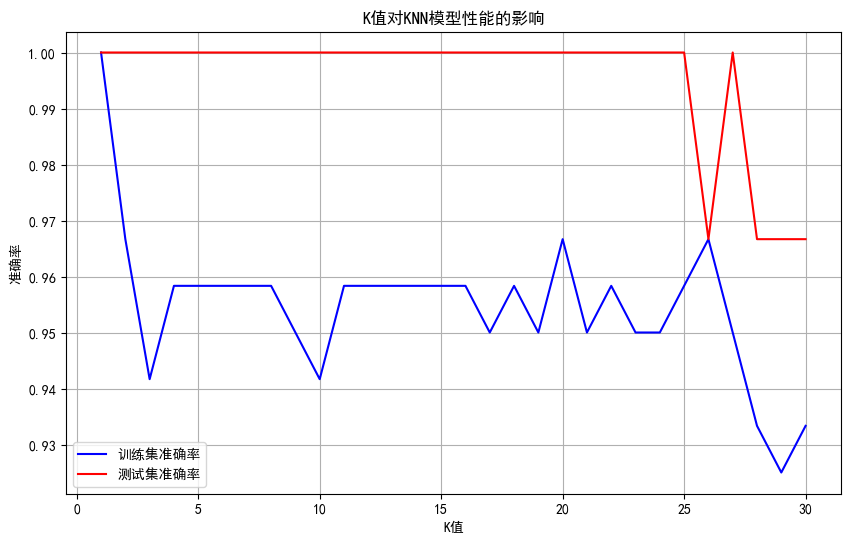

In [10]:
k_values = list(range(1, 31))
train_accuracies = []
test_accuracies = []
for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)

    # 训练集准确率
    y_train_pred = knn.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)

    # 测试集准确率
    y_test_pred = knn.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_accuracies.append(test_acc)
# 绘制K值影响曲线
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, 'b-', label='训练集准确率')
plt.plot(k_values, test_accuracies, 'r-', label='测试集准确率')
plt.xlabel('K值')
plt.ylabel('准确率')
plt.title('K值对KNN模型性能的影响')
plt.legend()
plt.grid(True)
plt.show()

# 实验要求

## 必做任务

1. **实现KNN核心算法：**
    - 完成欧氏距离、曼哈顿距离和余弦相似度的计算函数
    - 实现KNN分类器类
    - 支持不同距离度量方法的切换

2. **模型训练与评估：**
    - 在鸢尾花数据集上训练KNN模型
    - 评估模型在测试集上的准确率
    - 可视化混淆矩阵

3. **参数影响分析：**
    - 调整K值（1-30），绘制K值与准确率关系曲线
    - 比较不同距离度量方法对模型性能的影响

## 扩展任务

1. **加权KNN实现：**  
    - 根据距离为邻居赋予不同的权重（如 $1/d$）
    - 比较加权KNN与标准KNN的性能差异

2. **降维可视化：**  
    - 使用PCA或t-SNE将数据降至2维
    - 可视化KNN的决策边界

3. **KD树优化：**  
    - 使用KD树优化最近邻搜索效率
    - 比较暴力搜索与KD树搜索的性能差异

4. **多数据集测试：**  
    - 在乳腺癌数据集上测试KNN性能
    - 在手写数字数据集上测试KNN性能

# 实验分析

分析不同K值对模型性能的影响——预期输出分析：

1. **小K值（k=1）：**
    - 训练准确率高，测试准确率低
    - 模型复杂，对噪声敏感，容易过拟合

2. **中等K值（k=5-10）：**
    - 训练和测试准确率平衡
    - 模型泛化能力好

3. **大K值（k>20）：**
    - 训练和测试准确率均下降
    - 模型过于简单，可能欠拟合

# 思考题

1. **距离度量：**  
    - 欧氏距离和曼哈顿距离各有什么优缺点？  
    >  **答：** 欧氏距离适用于各维度尺度一致、特征连续的数据，能反映“直线”距离，但对异常值敏感。曼哈顿距离适用于高维稀疏数据，对异常值不敏感，但不能很好地反映空间“直线”距离。
    - 在什么情况下余弦相似度比欧氏距离更合适？  
    >  **答：** 当关注样本间方向而非绝对大小、特征为高维稀疏向量（如文本、推荐系统）时，余弦相似度更合适。

2. **特征缩放：**  
    - 为什么KNN算法对特征缩放如此敏感？  
    >  **答：** 因为KNN基于距离计算，若特征尺度差异大，尺度大的特征会主导距离，导致模型偏向某些特征。
    - 标准化和归一化哪种方法更适合KNN？为什么？  
    > **答：** 两者都可用，通常归一化（Min-Max）更常见于KNN，因为它将所有特征缩放到相同区间，有利于距离计算的公平性。

3. **维度灾难：**  
    - 高维数据对KNN性能有什么影响？  
    >  **答：** 高维空间中样本间距离趋于相等，KNN难以区分邻近关系，导致性能下降（维度灾难）。
    - 如何缓解高维数据带来的问题？  
    >  **答：** 可通过特征选择、降维（如PCA、t-SNE）等方法降低数据维度。

4. **计算效率：**  
    - KNN算法的主要计算瓶颈是什么？  
    >  **答：** 主要瓶颈在于对每个测试样本都需遍历全部训练样本计算距离，计算量大。
    - 有哪些方法可以提高KNN的计算效率？  
    >  **答：** 可采用KD树、球树等空间索引结构，或近似最近邻算法加速搜索。

5. **应用场景：**  
    - KNN在哪些实际应用场景中表现优异？  
    >  **答：** 在样本量适中、特征维度不高、数据分布简单的场景，如图像识别、推荐系统、异常检测等。
    - 在哪些场景中应该避免使用KNN？  
    >  **答：** 在高维数据、样本量极大或对实时性要求高的场景应避免使用KNN。

# 扩展阅读

1. **高级技术：**
    - 局部加权回归（Locally Weighted Regression）
    - 基于案例的推理（Case-Based Reasoning）
    - 学习向量量化（Learning Vector Quantization）

2. **实际应用：**
    - 推荐系统中的协同过滤
    - 图像分类中的相似度匹配
    - 异常检测中的最近邻方法

3. **优化技术：**
    - KD树与球树数据结构
    - 近似最近邻搜索算法
    - 距离度量学习方法